In [67]:
#libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [68]:
#dataset chosen
#penguin dataset
penguins=sns.load_dataset("penguins")
penguins.head(5)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


**Task 1**

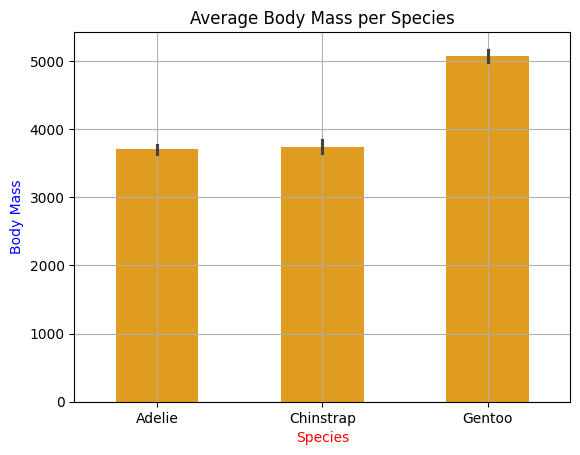

In [69]:
#bar plt comparing categories for a numeric column's average
#average body mass per species
sns.barplot(data=penguins, x="species", y="body_mass_g", color="orange", width=0.5)
plt.title("Average Body Mass per Species")
plt.xlabel("Species", color="red")
plt.ylabel("Body Mass", color="blue")
plt.grid(True)
plt.show()

**Task 2**

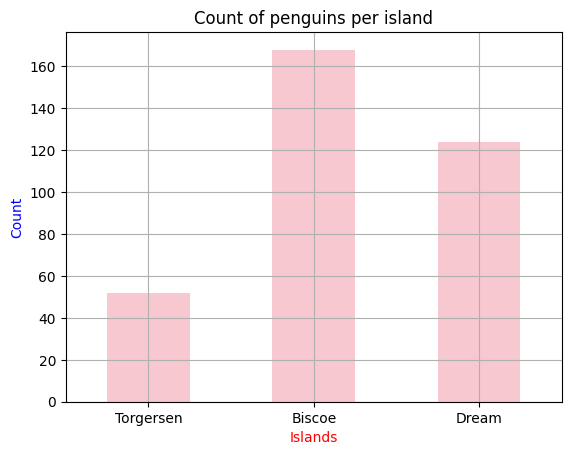

In [70]:
#counts for categories for a ocolumn

sns.countplot(data=penguins, x="island", color="pink", width=0.5)
plt.xlabel("Islands", color="red")
plt.ylabel("Count", color="blue")
plt.title("Count of penguins per island")
plt.grid(True)
plt.show()

The most common category (island for penguins) is Biscoe

**Task 3**

/tmp/ipykernel_682/1536115087.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


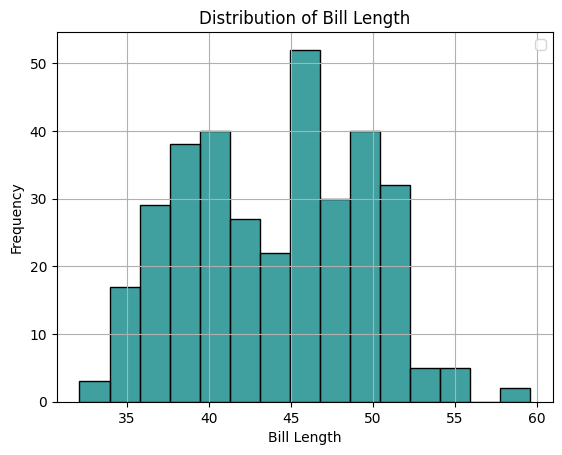

In [71]:
#histogram for one numeric column
#bill_length_mm
sns.histplot(data=penguins, x="bill_length_mm", color="Teal",  bins=15)
plt.title("Distribution of Bill Length")
plt.xlabel("Bill Length")
plt.ylabel("Frequency")
plt.grid(True)
plt.legend()
plt.show()

Bimodal and assymetrical

**Task 4**

Text(0.5, 1.0, 'Bill Length Boxplot')

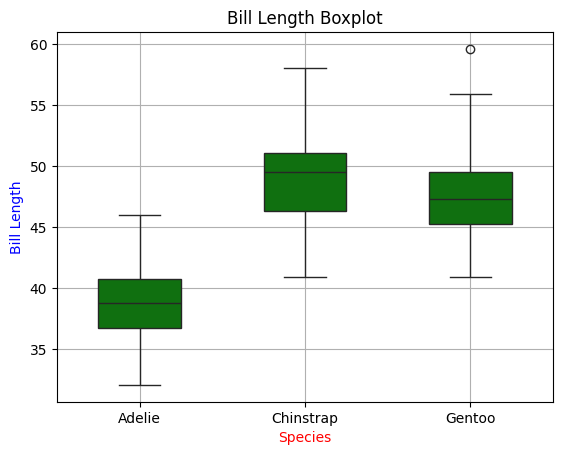

In [72]:
#bill length boxplot
sns.boxplot(data=penguins, x="species", y="bill_length_mm", color="green", width=0.5)
plt.xlabel("Species", color="red")
plt.grid(True)
plt.ylabel("Bill Length", color="blue")
plt.title("Bill Length Boxplot")

One outlier appear for Gentoo species for Bill_length_mm

**Task 5**

In [77]:
#outliers per species
species=penguins["species"].unique()
#print("Species names: ", species)
for specie in species:
  #column used bill length mm
  data=penguins[penguins["species"]==specie]
  Q1=data["bill_length_mm"].quantile(0.25)
  Q3=data["bill_length_mm"].quantile(0.75)
  IQR=Q3-Q1
  lower=Q1-1.5*IQR
  upper=Q3+1.5*IQR
  outliers=data[(data["bill_length_mm"]<lower) | (data["bill_length_mm"]>upper)]
  if not outliers.empty:
    print(f"Outliers for {specie} :", outliers)

Outliers for Gentoo :     species  island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
253  Gentoo  Biscoe            59.6           17.0              230.0   

     body_mass_g   sex  
253       6050.0  Male  


Yep, they match. Since i categorized the boxplot for species in the manual calculation I also had to categorize them by species, which means each specie basically gets their lower and upper boundaries separately calculated.

**Task 6**

In [79]:
#outlier detection z score comparison
from scipy import stats
for specie in species:
  data=penguins[penguins["species"]==specie]
  data["z_score"]=stats.zscore(data["bill_length_mm"])
  outliers_z=data[data["z_score"].abs()>1.5]
  print(f"Ouliters for {specie}: ", len(outliers_z))

Ouliters for Adelie:  0
Ouliters for Chinstrap:  9
Ouliters for Gentoo:  0


/tmp/ipykernel_682/3390747111.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["z_score"]=stats.zscore(data["bill_length_mm"])
/tmp/ipykernel_682/3390747111.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["z_score"]=stats.zscore(data["bill_length_mm"])
/tmp/ipykernel_682/3390747111.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pyda

They do not match because they use different baselines, szore uses mean while IQR/Boxplot uses median as a baseline.

**Task 7**

Text(0, 0.5, 'Bill Depth')

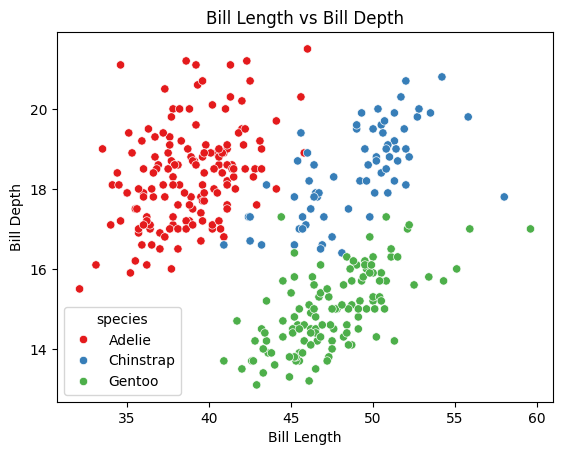

In [93]:
sns.scatterplot(data=penguins, x="bill_length_mm", y="bill_depth_mm", hue="species", palette="Set1")
plt.title("Bill Length vs Bill Depth")
plt.xlabel("Bill Length")
plt.ylabel("Bill Depth")
plt.show()

I lowkey see a positive scatter plot relationship, because for each specie as the bill length increases the bill depth also increases.

**Task 8**

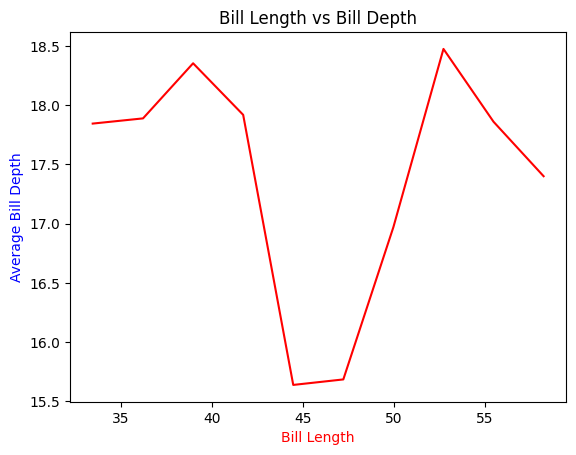

In [101]:
#sorted bill_length_mm
penguins["bill_length_mm"].sort_values()
data=penguins["bill_length_mm"]

#creating bins
penguins["bins"]=pd.cut(penguins["bill_length_mm"], bins=10)
penguins["bin_center"]=penguins["bins"].apply(lambda x: x.mid)

#avg bill depth for that bin
avg_for_bin = penguins.groupby("bin_center", observed=True)["bill_depth_mm"].mean()

sns.lineplot(x=avg_for_bin.index, y=avg_for_bin.values, color="red")
plt.title("Bill Length vs Bill Depth")
plt.xlabel("Bill Length", color="red")
plt.ylabel("Average Bill Depth", color="blue")
plt.show()


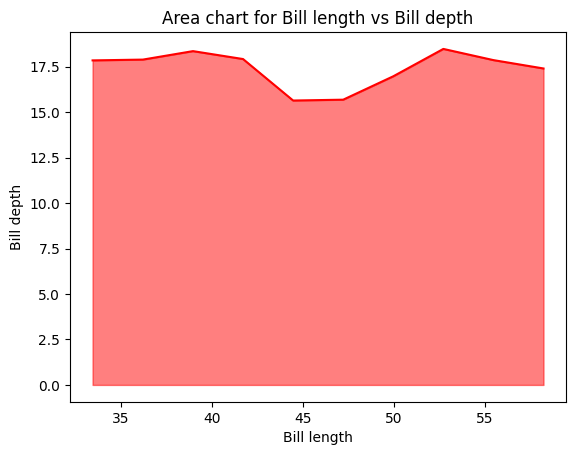

In [109]:
plt.plot(avg_for_bin.index, avg_for_bin.values, color="red")
plt.fill_between(avg_for_bin.index, avg_for_bin.values, color="red", alpha=0.5)
plt.title("Area chart for Bill length vs Bill depth")
plt.xlabel("Bill length")
plt.ylabel("Bill depth")
plt.show()

area charts are usually used to represent volume and can be used to repesent like contributions of things in a bigger picture

**Task 9**

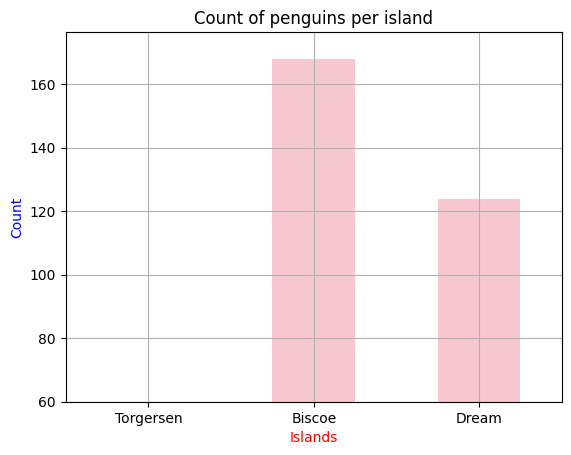

In [107]:
#counts for categories for a ocolumn

sns.countplot(data=penguins, x="island", color="pink", width=0.5)
plt.ylim(bottom=60)
plt.xlabel("Islands", color="red")
plt.ylabel("Count", color="blue")
plt.title("Count of penguins per island")
plt.grid(True)
plt.show()

BASICALLY THE YLIM ACTS AS A CUTOFF NOW FOR COUNTS, FOR EXAMPLE HERE I PUT YLIM=60 AND ISLADS BELOW THE COUNT OF 60 DO NOT SHOW, THIS CRITERIA CAN BE USED TO LIMIT WHAT CATEGORIES WE WANT TO VIEW.